# Práctica de Percepción: Detección de carácteristicas y clasificación
## Introducción
En esta práctica veremos como detectar diferentes características de imágenes y como clasificar imágenes. Para ello se utilizará OpenCV, NumPy y Matplotlib. Así mismo se usará scikit-learn para los clasificadores.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def imshow(img, title=""):
    if len(img.shape)==2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

/home/antonio/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Ejercicio 1: Gradiente
Objetivos: Calcular y comparar diferentes tipos de métodos para calcular el gradiente. Usar las funciones de OpenCV. 

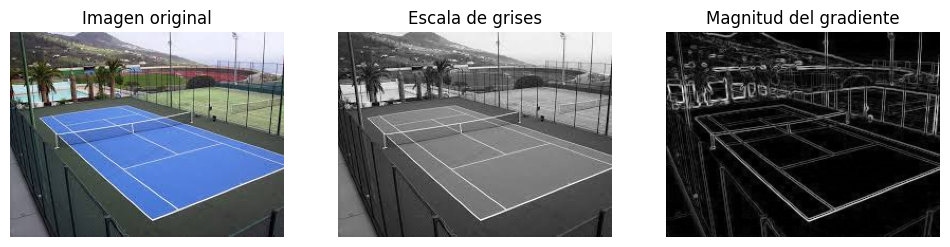

In [2]:
# Cargar imagen
img = cv2.imread("images/tenis.jpeg")

# Convertir BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convertir a gris
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Gradientes Sobel

gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Magnitud del gradiente
G = np.sqrt(gx**2 + gy**2)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Imagen original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Escala de grises")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Magnitud del gradiente")
plt.imshow(G, cmap="gray")
plt.axis("off")

plt.show()

Ejercicio propuesto: implementar con las funciones de OpenCV el cálculo con Prewitt y Laplaciano. 

In [3]:
#TODO

## Ejercicio 2: Caracterización de texturas con gradiente
Objetivos: Usando las funciones anteriores, crear una funcion que calcule la densidad de puntos cuyo gradiente G cumple abs(G)>U, siendo U un parámetro de entrada entre 0 y 1. Comparar diferentes imágenes de la carpeta textures.

In [4]:
#To Do

## Ejercicio 3: Detección de esquinas
Objetivos: Usar el detector de esquinas de Harris.

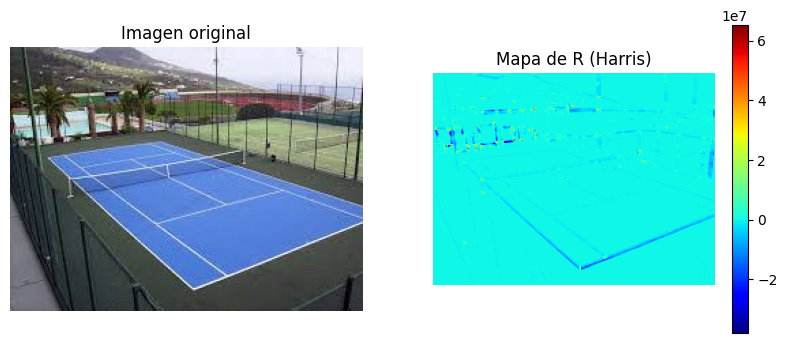

In [5]:
img = cv2.imread("images/tenis.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Parámetros de Harris
block_size = 2      # Tamaño del vecindario
ksize = 3           # Tamaño del filtro Sobel
k = 0.04            # Constante Harris (0.04-0.06 típico)

# R = det(M) - k * (trace(M))^2
R = cv2.cornerHarris(gray, block_size, ksize, k)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Imagen original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mapa de R (Harris)")
plt.imshow(R, cmap='jet')
plt.colorbar()
plt.axis("off")
plt.show()

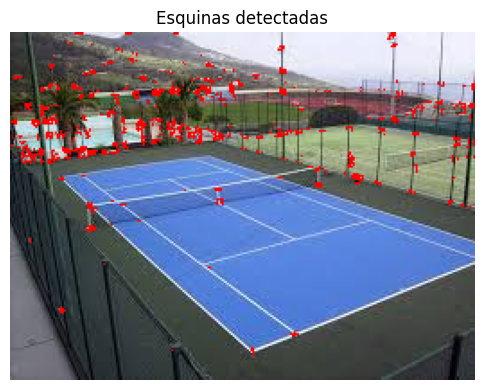

In [6]:
# Umbral para marcar esquinas
threshold = 0.01 * R.max()
img_harris = img_rgb.copy()
img_harris[R > threshold] = [255, 0, 0]  # rojo

plt.figure(figsize=(6,6))
plt.title("Esquinas detectadas")
plt.imshow(img_harris)
plt.axis("off")
plt.show()

## Ejercicio 4: Clasificación usando scikit-learn
Objetivos: Aprender a usar scikit-learn para ajustar clasificadores, y utilizarlos. Mostrar los tres métodos usados en clase.

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


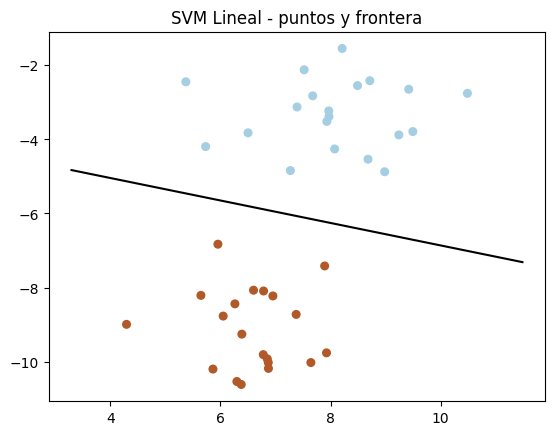

In [7]:
#SVM

from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Crear datos
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

# 2. Entrenar SVM lineal
clf = svm.SVC(kernel="linear")
clf.fit(X, y)

# 3. Dibujar puntos
plt.scatter(X[:,0], X[:,1], c=y, s=30, cmap=plt.cm.Paired)

# 4. Dibujar frontera
# obtenemos los coeficientes de la recta: w0*x + w1*y + b = 0
w = clf.coef_[0]
b = clf.intercept_[0]
x_plot = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_plot = -(w[0]/w[1])*x_plot - b/w[1]
plt.plot(x_plot, y_plot, 'k-')  # línea de decisión

plt.title("SVM Lineal - puntos y frontera")
plt.show()

Ejercicio propuesto: crear una función que discrimine entre clase A y clase B, dado los parámetros de la recta y las características. Probar con (-5,3), (-2,7), (-10,4).

In [8]:
#To Do

Ejercicio propuesto: realizar un discriminante por distancia, usando para ello el dataset anterior. 

In [9]:
#To Do

## Ejercicio 5: Miniproyecto
Ejercicio propuesto: realizar un pipeline para clasificar una imagen en dos tipos diferentes. El alumno deberá elegir dos tipos de imágenes diferentes, a las cuales le tendrá que obtener, al menos, dos características diferentes. Se deberá generar un pequeño dataset para entrenar el clasificador. Finalmente, validar el clasificador con imágenes no utilizadas en el entrenamiento.

Ejemplos de imágenes: cesped vs pared rocosa, cielo nublado vs despejado, tela vs madera.
Ejemplos de carácterísticas: texturas, color.

In [10]:
#To Do